In [1]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Global plotting quality (applies to all subsequent plots)
plt.rcParams['figure.dpi'] = 170
plt.rcParams['savefig.dpi'] = 320
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 1.8
plt.rcParams['axes.grid'] = True

In [2]:
df = pandas.read_csv("experiment_results_summary.csv")
print(df.head())

   run_id            timestamp  agent_count  seed  field_seed  max_steps  \
0       8  2026-04-07T22:04:53            3     8    20260407       7500   
1       3  2026-04-07T22:04:53            3     3    20260407       7500   
2       5  2026-04-07T22:04:53            3     5    20260407       7500   
3       1  2026-04-07T22:04:53            3     1    20260407       7500   
4       7  2026-04-07T22:04:53            3     7    20260407       7500   

   steps_executed  converged  converge_step  best_field_final  \
0             912          1            912          -131.283   
1            1525          1           1525          -131.809   
2            1537          1           1537          -131.903   
3            1434          1           1434          -131.916   
4            1971          1           1971          -131.965   

   mean_field_final  best_field_min_over_run  improvement_from_start  \
0          -99.8438                 -132.295                 92.4472   
1       

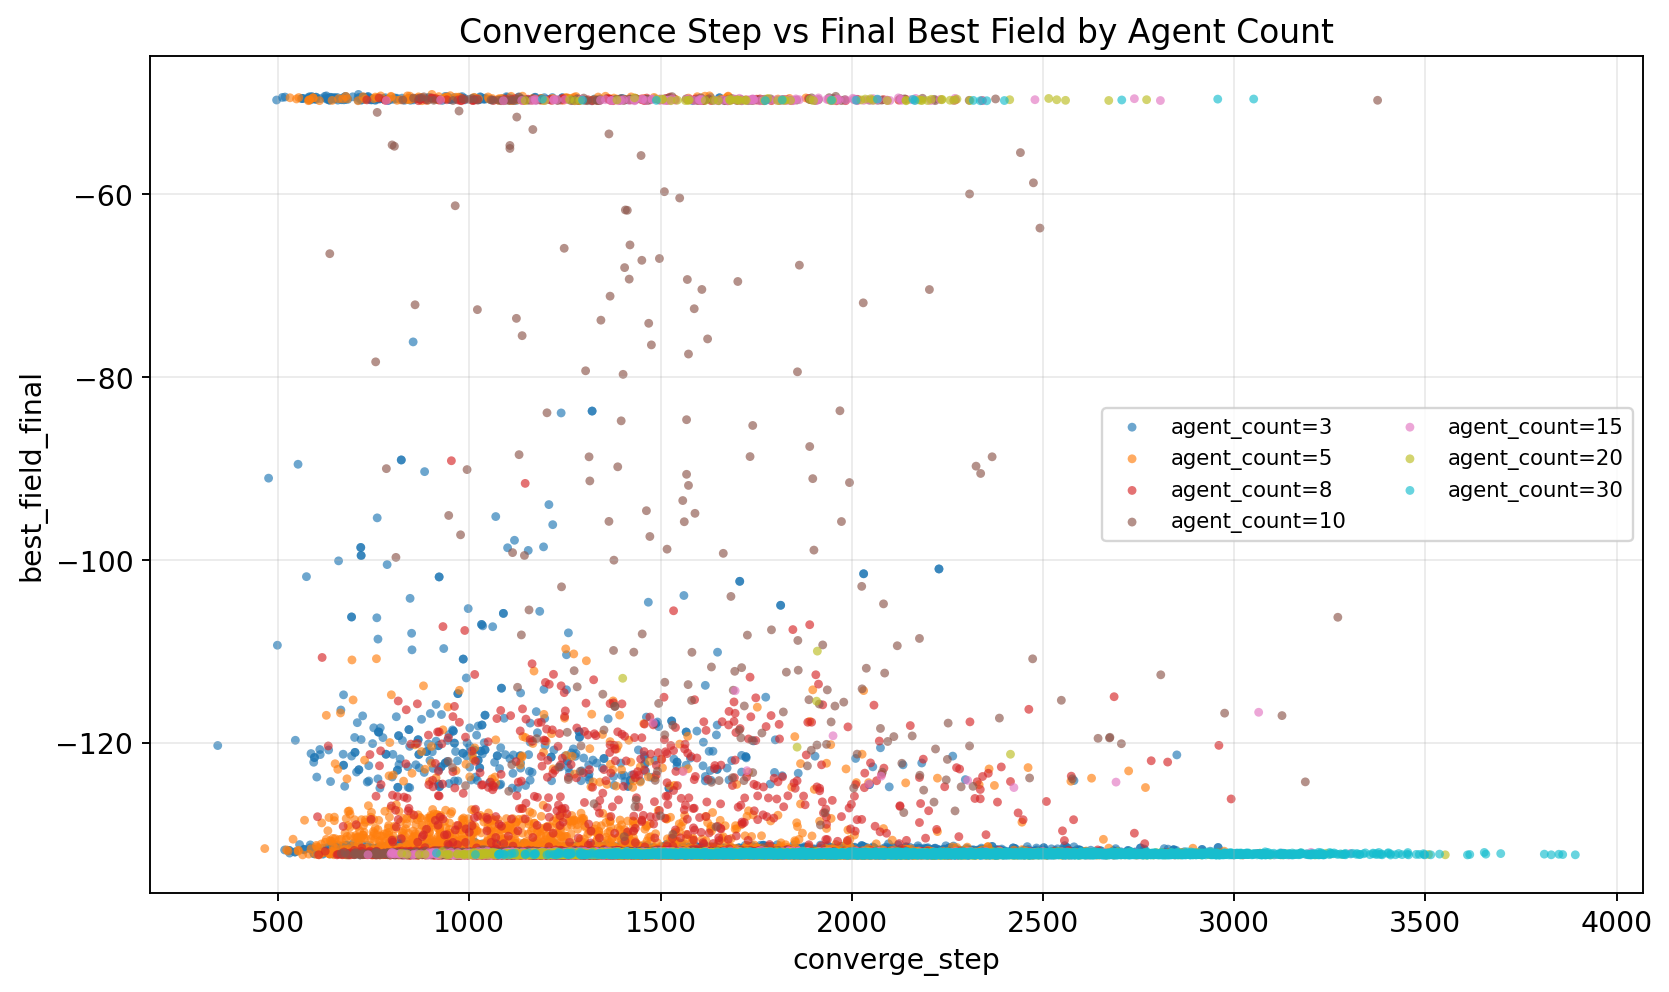

In [5]:
# Scatter: converge_step vs best_field_final (colored by agent_count)
plt.figure(figsize=(10, 6))

agent_counts = sorted(df['agent_count'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(agent_counts)))

for color, count in zip(colors, agent_counts):
    subset = df[df['agent_count'] == count]
    plt.scatter(
        subset['converge_step'],
        subset['best_field_final'],
        s=14,
        alpha=0.65,
        label=f'agent_count={count}',
        color=color,
        edgecolors='none'
    )

plt.xlabel('converge_step')
plt.ylabel('best_field_final')
plt.title('Convergence Step vs Final Best Field by Agent Count')
plt.grid(alpha=0.25)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

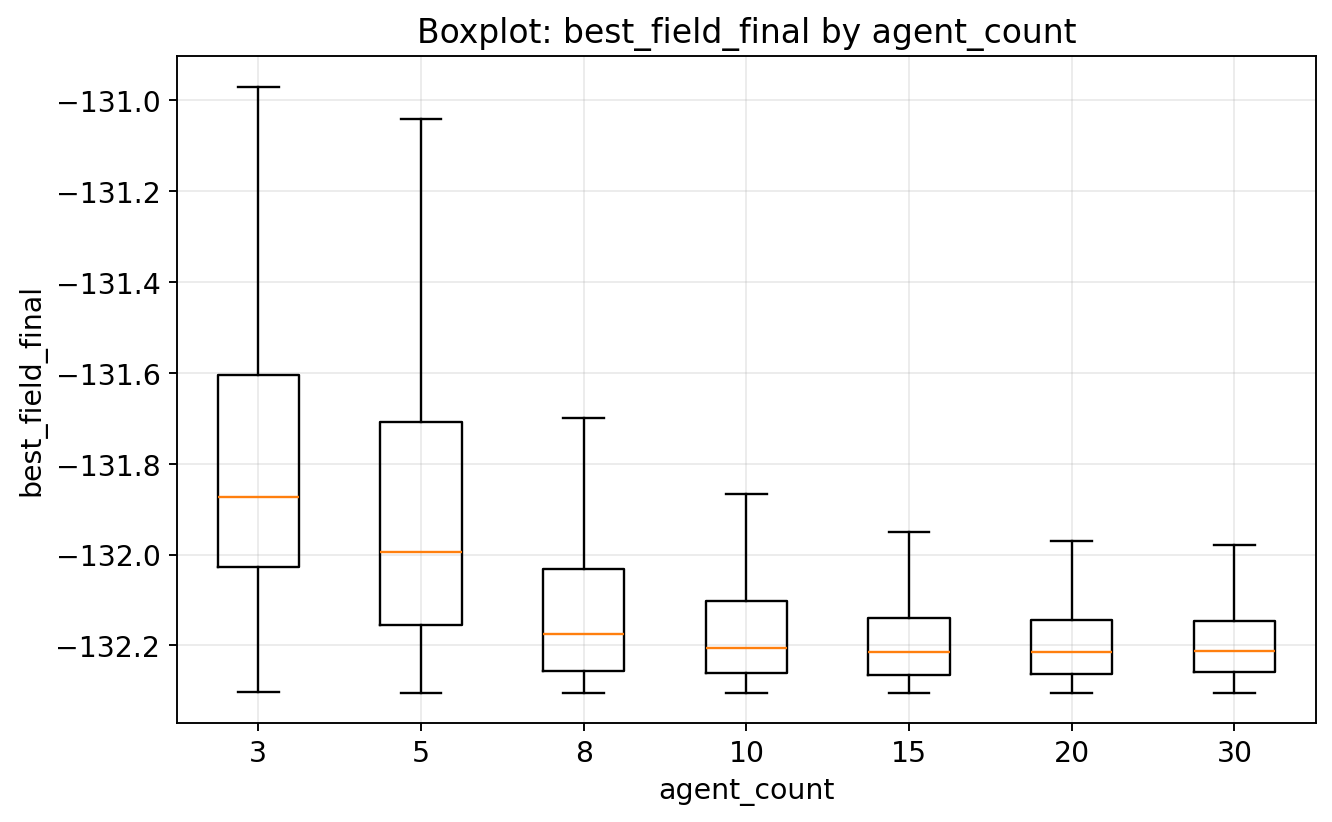

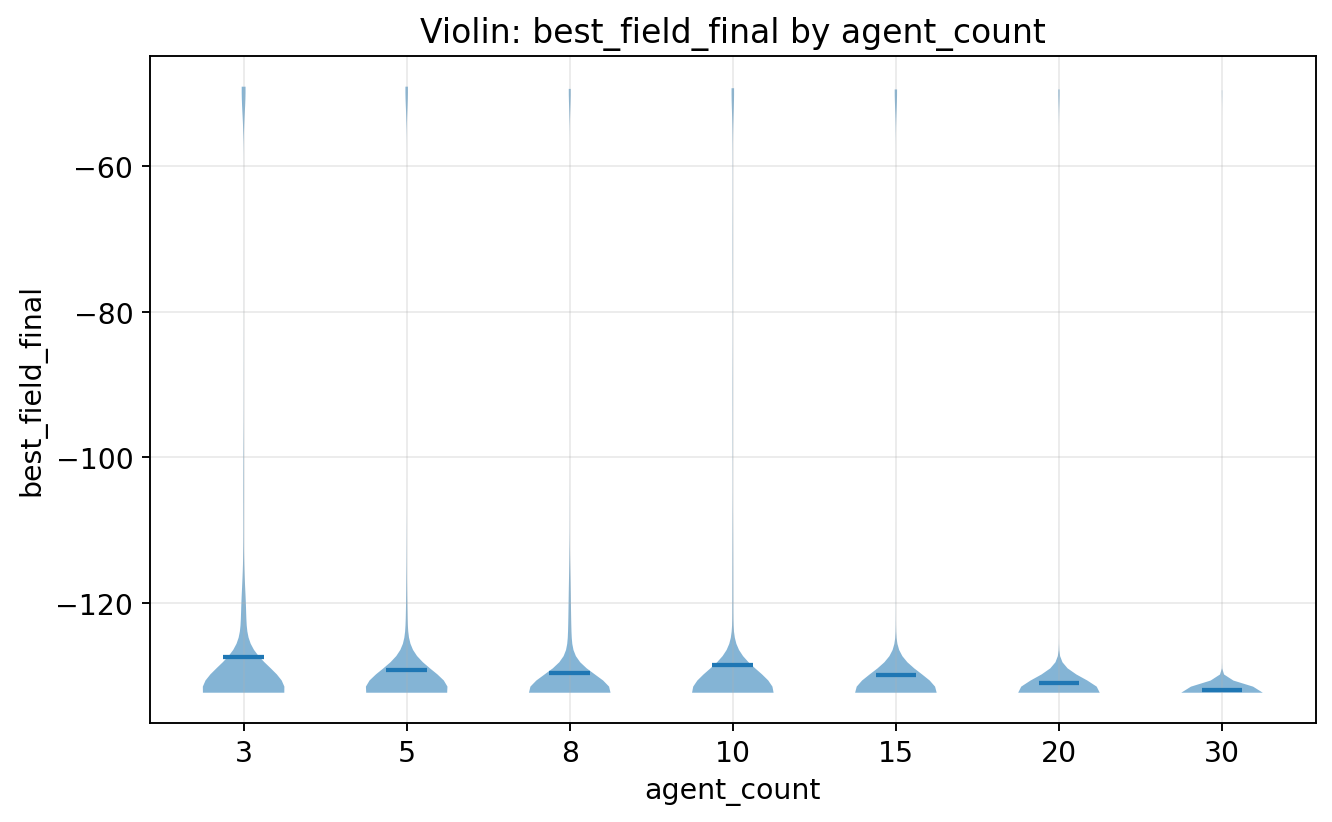

In [4]:
# Boxplot / Violin plot: best_field_final by agent_count (unlinked)
agent_counts_sorted = sorted(df['agent_count'].unique())
group_data = [df.loc[df['agent_count'] == c, 'best_field_final'].values for c in agent_counts_sorted]

# Boxplot (single figure)
plt.figure(figsize=(8, 5))
plt.boxplot(group_data, tick_labels=agent_counts_sorted, showfliers=False)
plt.title('Boxplot: best_field_final by agent_count')
plt.xlabel('agent_count')
plt.ylabel('best_field_final')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Violin plot (single figure)
plt.figure(figsize=(8, 5))
parts = plt.violinplot(group_data, showmeans=True, showmedians=False, showextrema=False)
for pc in parts['bodies']:
    pc.set_alpha(0.55)
plt.xticks(range(1, len(agent_counts_sorted) + 1), agent_counts_sorted)
plt.title('Violin: best_field_final by agent_count')
plt.xlabel('agent_count')
plt.ylabel('best_field_final')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

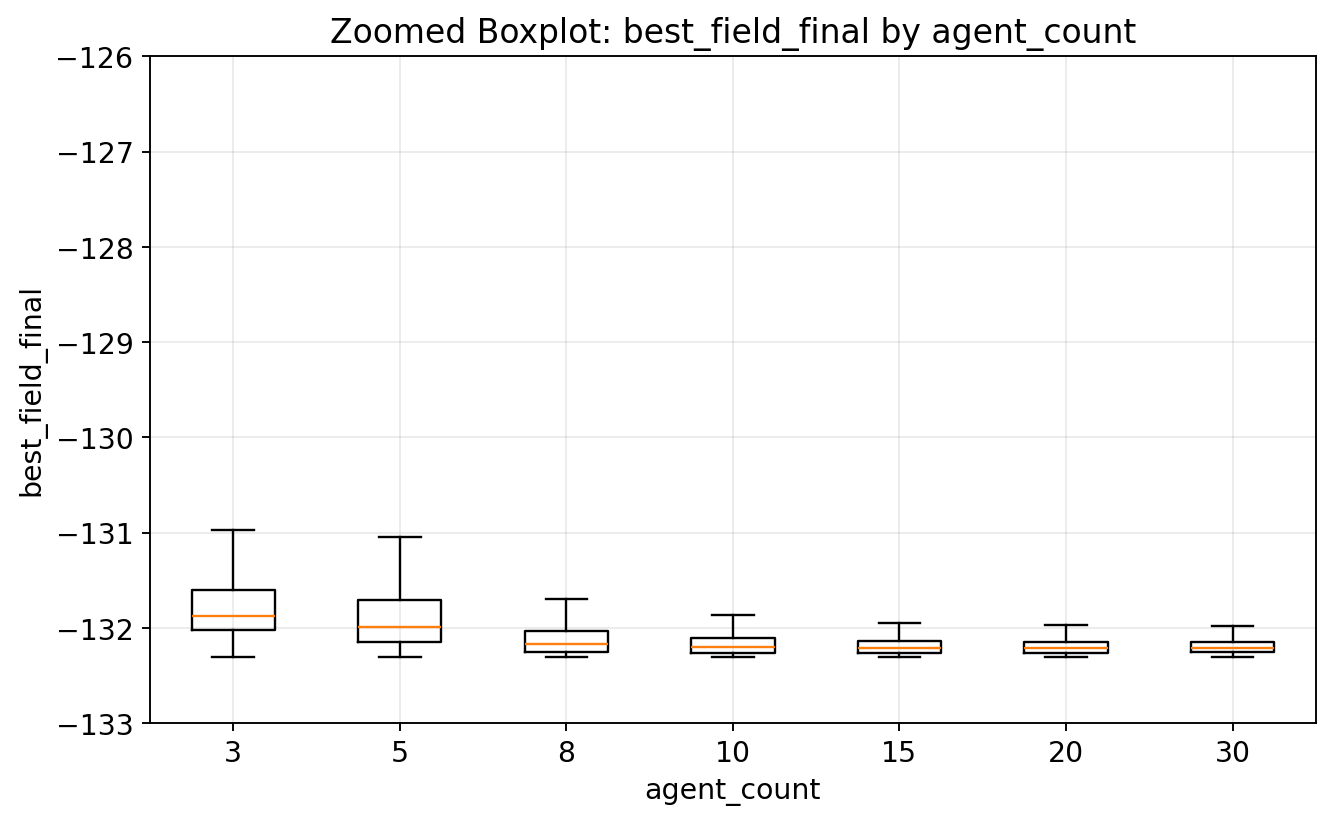

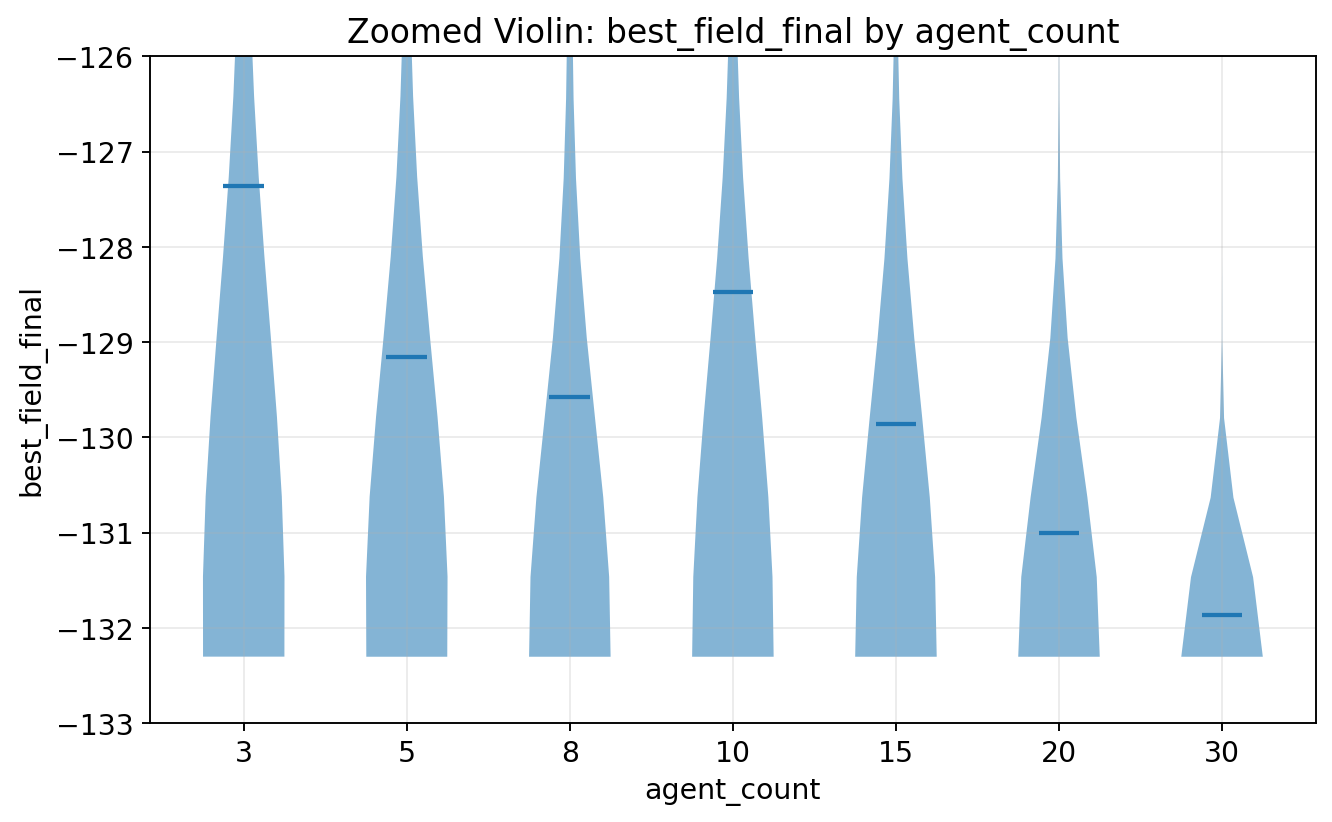

In [6]:
# Zoomed Boxplot / Violin: best_field_final by agent_count (unlinked)
agent_counts_sorted = sorted(df['agent_count'].unique())
group_data = [df.loc[df['agent_count'] == c, 'best_field_final'].values for c in agent_counts_sorted]

ymin, ymax = -133, -126

# Zoomed boxplot (single figure)
plt.figure(figsize=(8, 5))
plt.boxplot(group_data, tick_labels=agent_counts_sorted, showfliers=False)
plt.title('Zoomed Boxplot: best_field_final by agent_count')
plt.xlabel('agent_count')
plt.ylabel('best_field_final')
plt.ylim(ymin, ymax)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Zoomed violin plot (single figure)
plt.figure(figsize=(8, 5))
parts = plt.violinplot(group_data, showmeans=True, showmedians=False, showextrema=False)
for pc in parts['bodies']:
    pc.set_alpha(0.55)
plt.xticks(range(1, len(agent_counts_sorted) + 1), agent_counts_sorted)
plt.title('Zoomed Violin: best_field_final by agent_count')
plt.xlabel('agent_count')
plt.ylabel('best_field_final')
plt.ylim(ymin, ymax)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

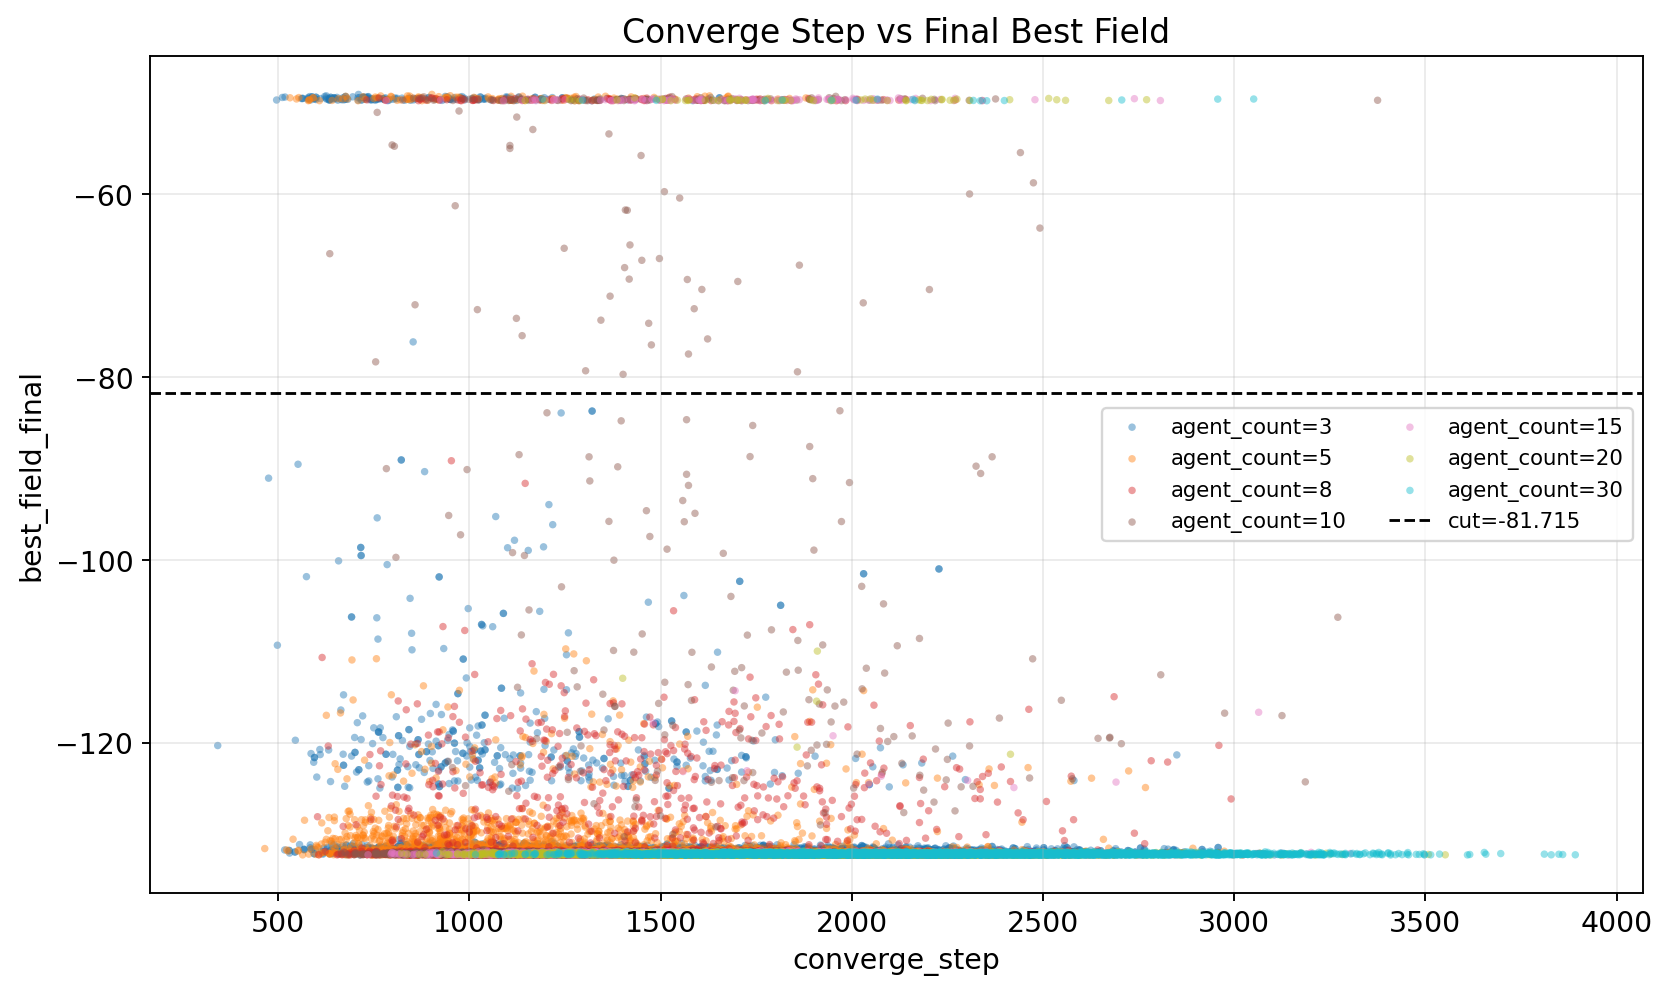

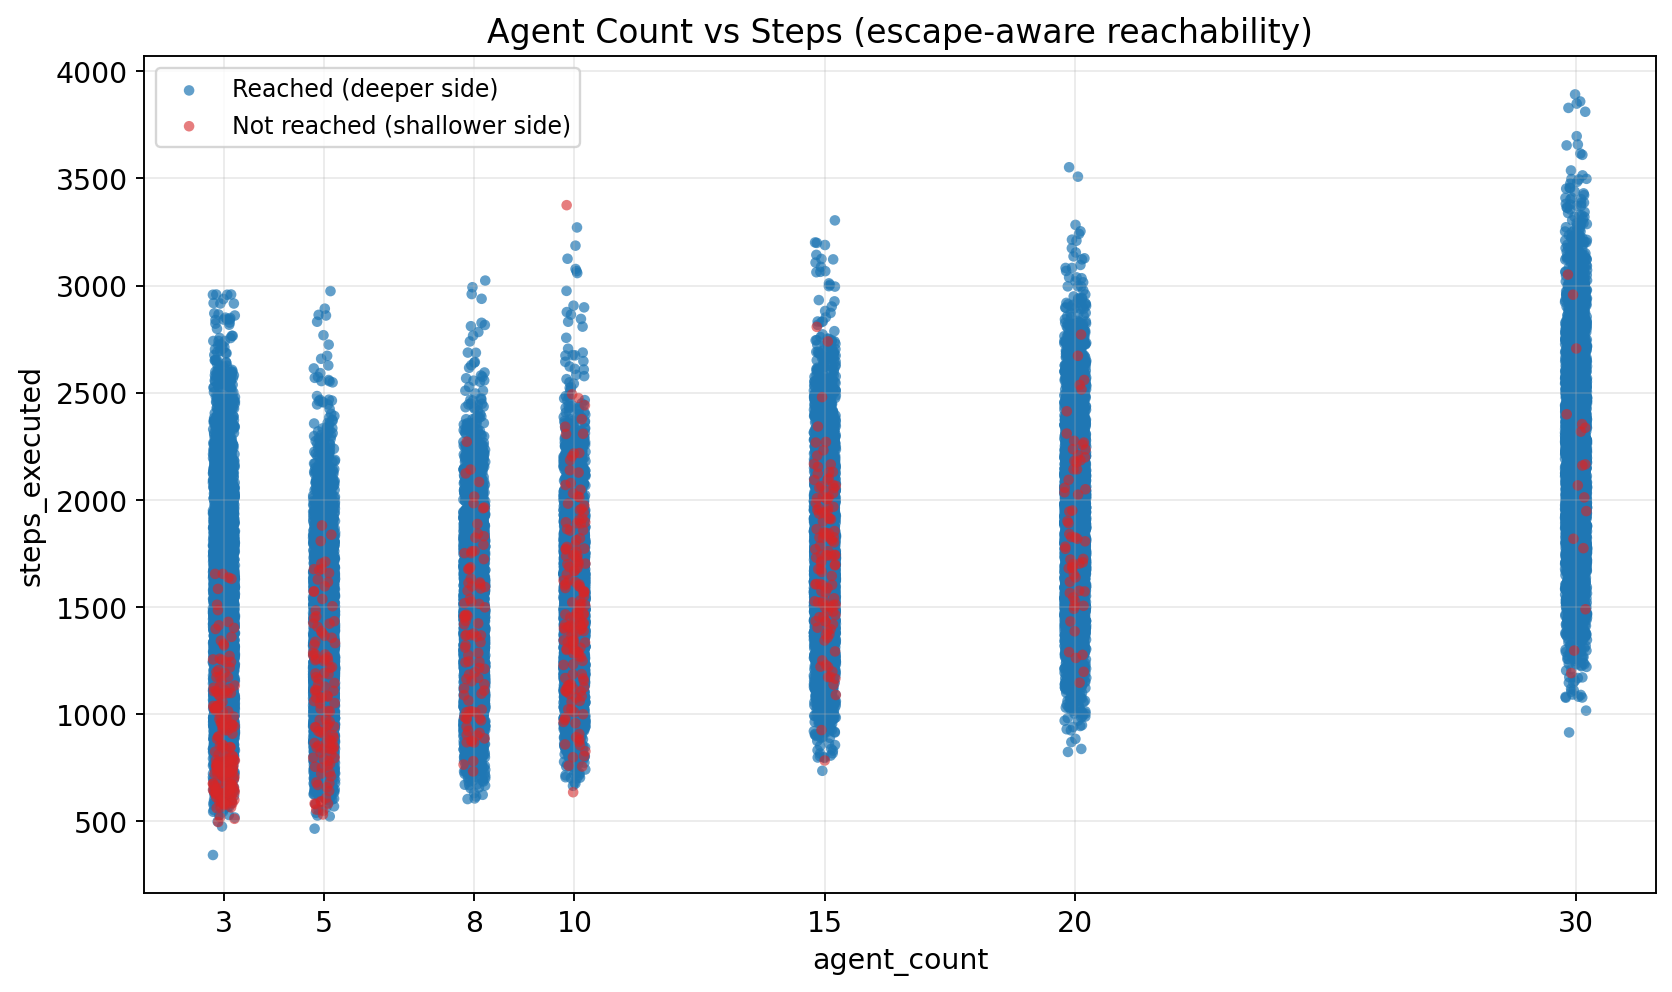

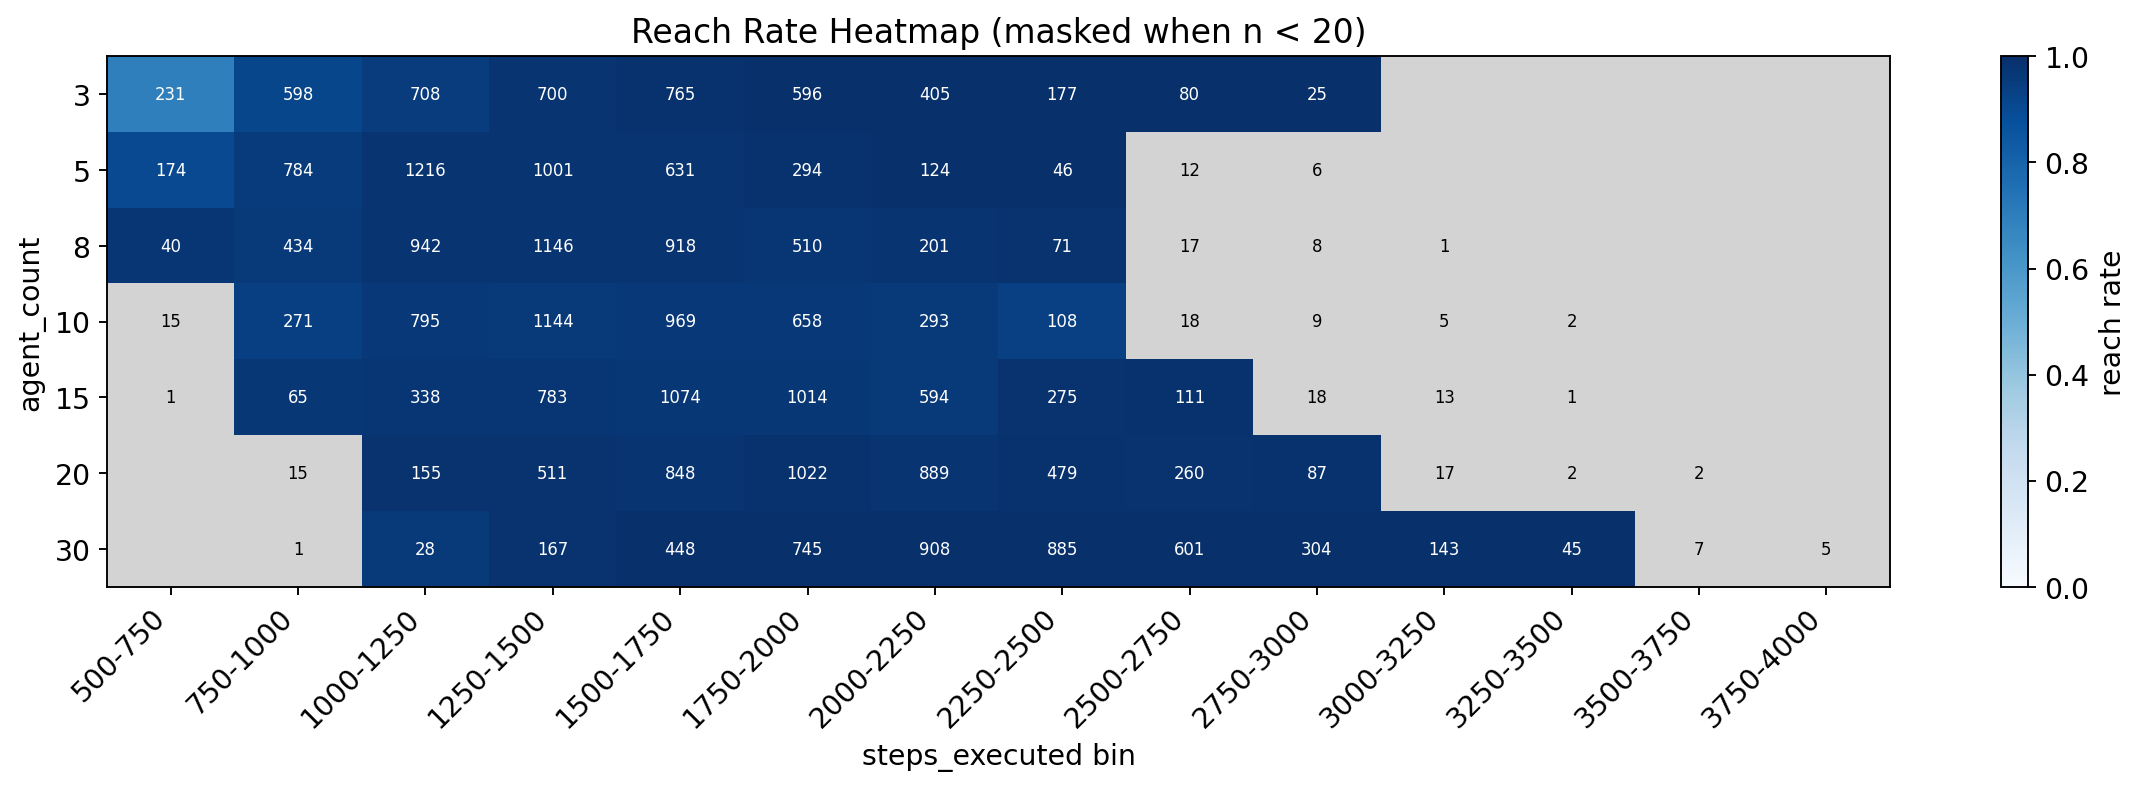

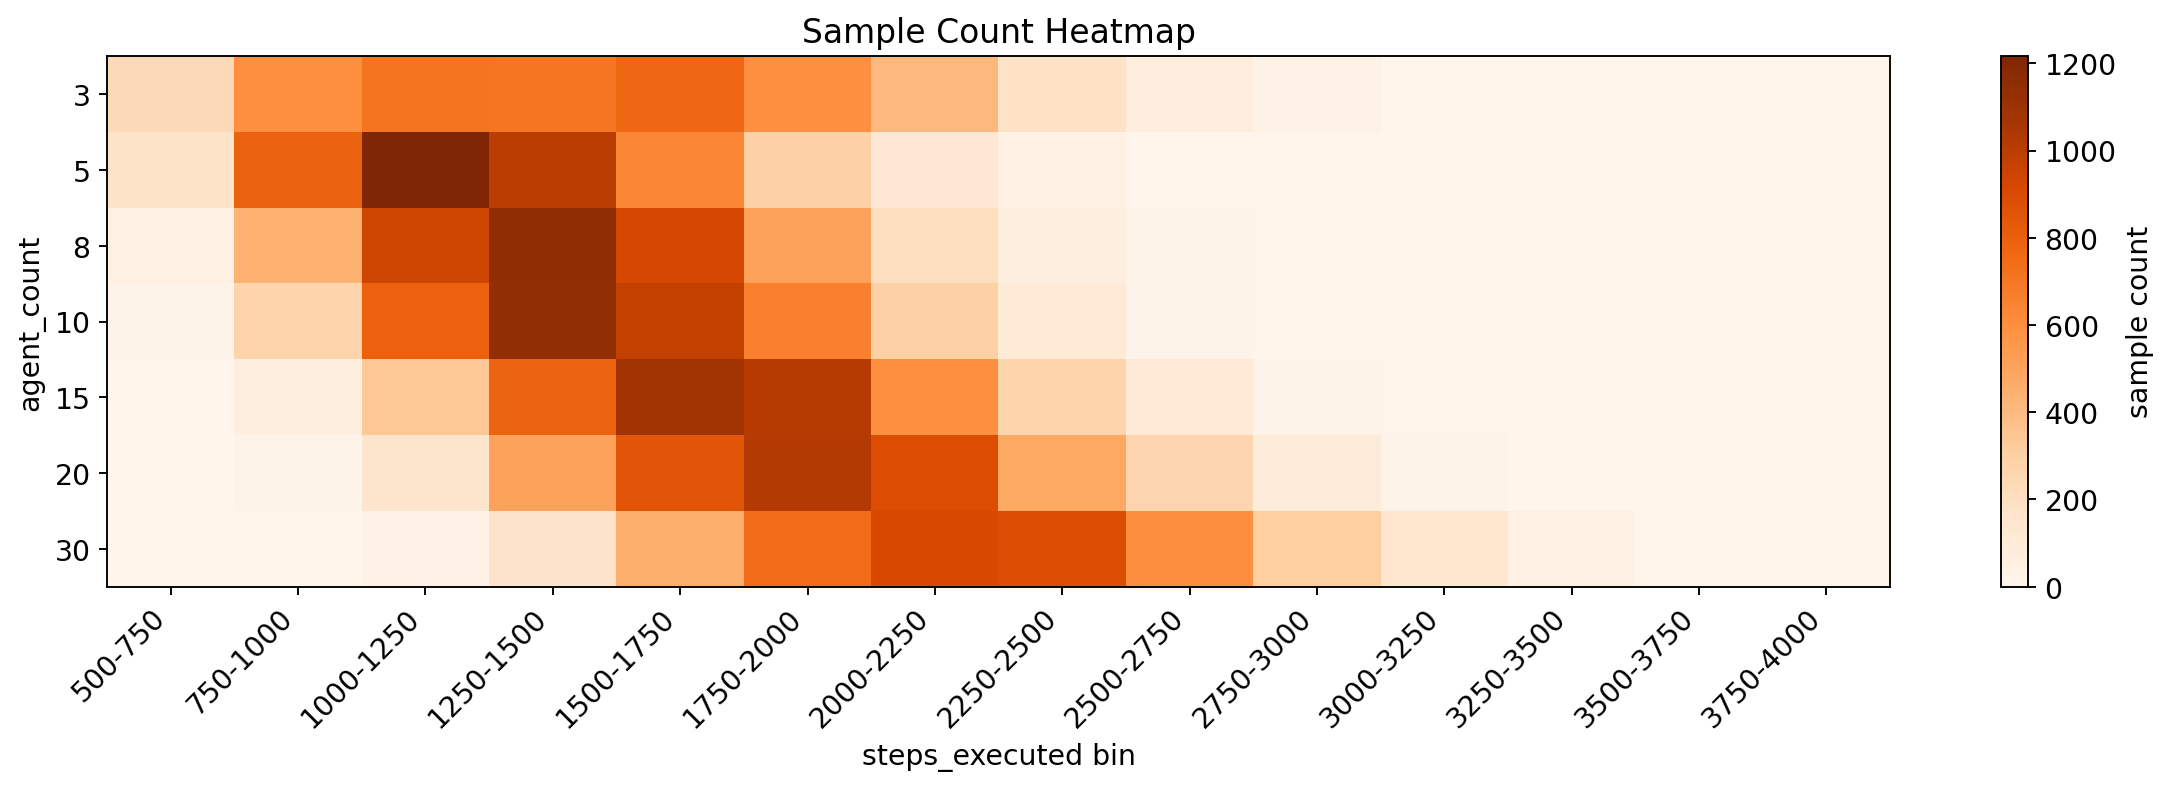

escape cut_y: -81.714750
reached ratio (escape-aware): 0.975 (29263/30014)


In [8]:
# Escape-aware trade-off + heatmaps (all plots unlinked)
# Loose cut logic: use the largest gap over the full best_field_final distribution.

vals = np.sort(df['best_field_final'].to_numpy())
gaps = np.diff(vals)
max_gap_idx = int(np.argmax(gaps))
cut_y = float((vals[max_gap_idx] + vals[max_gap_idx + 1]) / 2)

# "Reached" := deeper side of the cut (more negative final value)
reached_escape = df['best_field_final'] <= cut_y

# 0) Restore cut-line scatter: converge_step vs best_field_final
plt.figure(figsize=(10, 6))
agent_counts = sorted(df['agent_count'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(agent_counts)))
for color, count in zip(colors, agent_counts):
    subset = df[df['agent_count'] == count]
    plt.scatter(
        subset['converge_step'],
        subset['best_field_final'],
        s=10,
        alpha=0.45,
        color=color,
        edgecolors='none',
        label=f'agent_count={count}'
    )
plt.axhline(cut_y, color='black', linestyle='--', linewidth=1.2, label=f'cut={cut_y:.3f}')
plt.xlabel('converge_step')
plt.ylabel('best_field_final')
plt.title('Converge Step vs Final Best Field')
plt.grid(alpha=0.25)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# 1) Scatter: agent_count vs steps_executed (blue/red)
rng = np.random.default_rng(42)
x_jitter = df['agent_count'] + rng.uniform(-0.22, 0.22, size=len(df))

plt.figure(figsize=(10, 6))
plt.scatter(
    x_jitter[reached_escape],
    df.loc[reached_escape, 'steps_executed'],
    c='tab:blue', s=20, alpha=0.7, edgecolors='none',
    label='Reached (deeper side)'
)
plt.scatter(
    x_jitter[~reached_escape],
    df.loc[~reached_escape, 'steps_executed'],
    c='tab:red', s=20, alpha=0.6, edgecolors='none',
    label='Not reached (shallower side)'
)
plt.xticks(sorted(df['agent_count'].unique()))
plt.xlabel('agent_count')
plt.ylabel('steps_executed')
plt.title('Agent Count vs Steps (escape-aware reachability)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Heatmap: reach rate by (agent_count, step_bin), masked when sample count is too small
step_bins = np.arange(500, 4001, 250)
heat_df = df[['agent_count', 'steps_executed']].copy()
heat_df['reached_escape'] = reached_escape
heat_df['step_bin'] = pandas.cut(heat_df['steps_executed'], bins=step_bins, include_lowest=True, right=False)

rate_tbl = heat_df.pivot_table(index='agent_count', columns='step_bin', values='reached_escape', aggfunc='mean', observed=False)
count_tbl = heat_df.pivot_table(index='agent_count', columns='step_bin', values='reached_escape', aggfunc='size', fill_value=0, observed=False)

# Align count table columns to rate table columns to avoid shape mismatch
count_for_rate = count_tbl.reindex(columns=rate_tbl.columns, fill_value=0)

min_count = 20
rate_masked = rate_tbl.where(count_for_rate >= min_count)

cmap_rate = plt.cm.Blues.copy()
cmap_rate.set_bad(color='lightgray')

plt.figure(figsize=(14, 4.8))
im = plt.imshow(rate_masked.to_numpy(dtype=float), aspect='auto', cmap=cmap_rate, vmin=0, vmax=1, interpolation='nearest')
plt.colorbar(im, label='reach rate')
plt.yticks(range(len(rate_masked.index)), rate_masked.index)
col_labels = [f"{int(iv.left)}-{int(iv.right)}" for iv in rate_masked.columns]
plt.xticks(range(len(col_labels)), col_labels, rotation=45, ha='right')
plt.xlabel('steps_executed bin')
plt.ylabel('agent_count')
plt.title(f'Reach Rate Heatmap (masked when n < {min_count})')
plt.grid(False)

# annotate sample counts in each cell (dynamic text color for readability)
counts_np = count_for_rate.to_numpy()
rate_np = rate_masked.to_numpy(dtype=float)
for i in range(rate_np.shape[0]):
    for j in range(rate_np.shape[1]):
        n_ij = int(counts_np[i, j])
        if n_ij > 0:
            r_ij = rate_np[i, j]
            if np.isnan(r_ij):
                txt_color = 'black'
            else:
                txt_color = 'white' if r_ij >= 0.55 else 'black'
            plt.text(j, i, str(n_ij), ha='center', va='center', fontsize=7, color=txt_color)

plt.tight_layout()
plt.show()

# 3) Heatmap: sample count by (agent_count, step_bin)
plt.figure(figsize=(14, 4.8))
im2 = plt.imshow(count_tbl.to_numpy(dtype=float), aspect='auto', cmap='Oranges', interpolation='nearest')
plt.colorbar(im2, label='sample count')
plt.yticks(range(len(count_tbl.index)), count_tbl.index)
col_labels = [f"{int(iv.left)}-{int(iv.right)}" for iv in count_tbl.columns]
plt.xticks(range(len(col_labels)), col_labels, rotation=45, ha='right')
plt.xlabel('steps_executed bin')
plt.ylabel('agent_count')
plt.title('Sample Count Heatmap')
plt.grid(False)
plt.tight_layout()
plt.show()

print(f'escape cut_y: {cut_y:.6f}')
print(f'reached ratio (escape-aware): {reached_escape.mean():.3f} ({reached_escape.sum()}/{len(df)})')

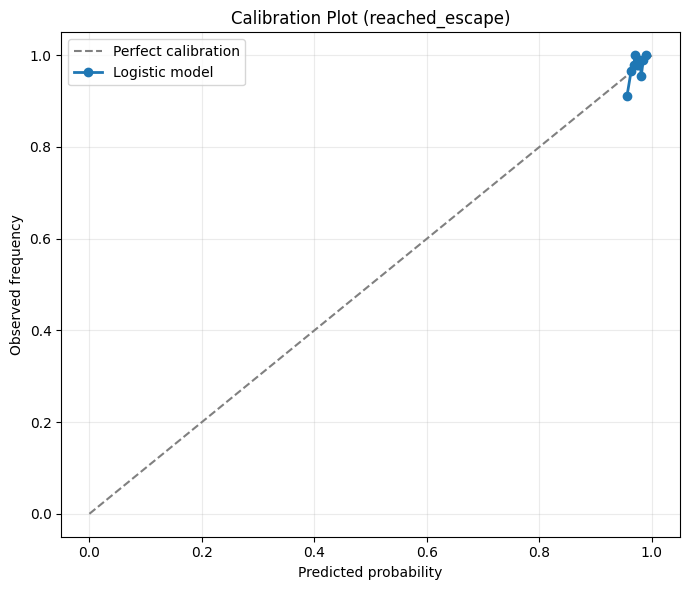

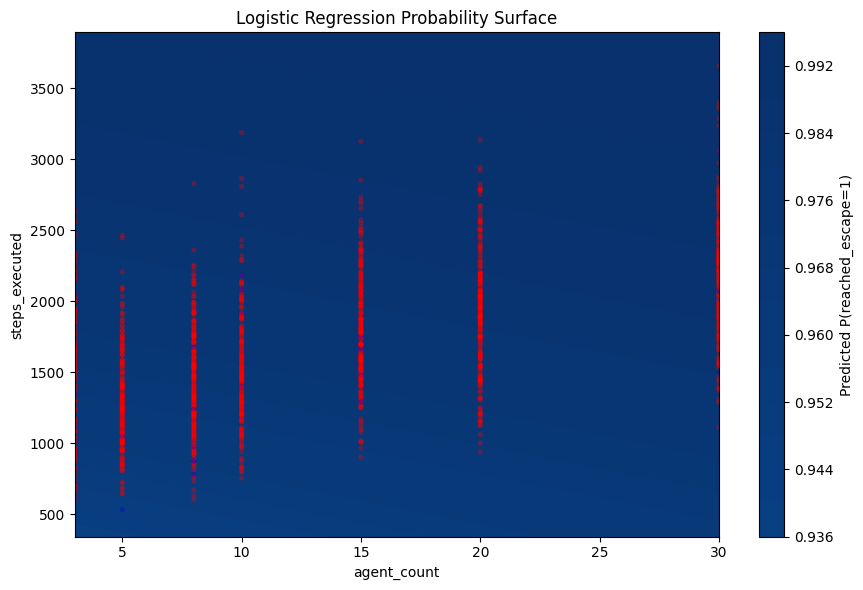

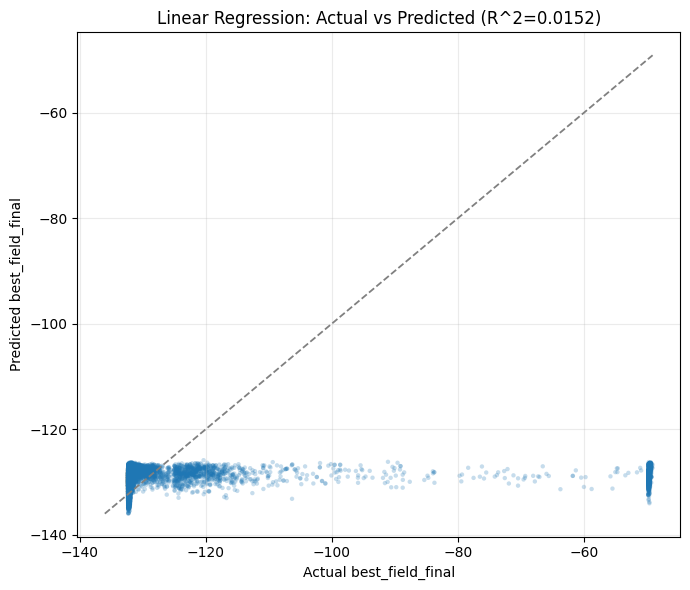

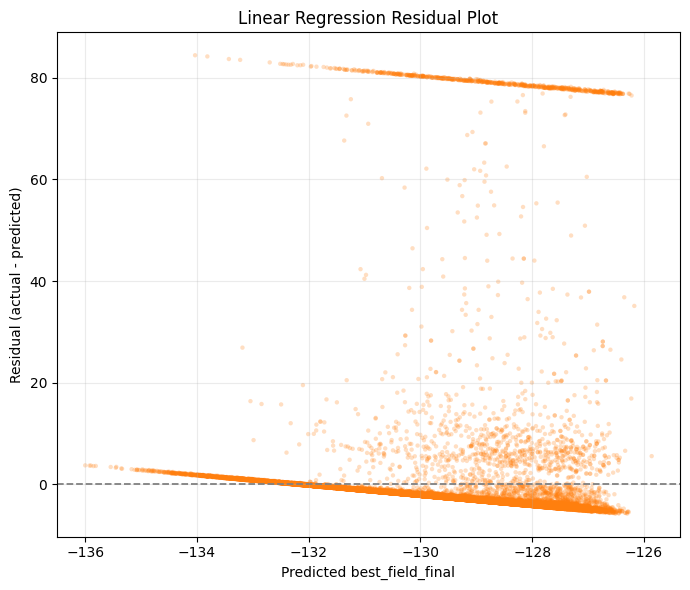

Loose cut_y used for logistic target: -81.714750
Logistic AUC: 0.6696, Brier: 0.0246
Linear model: best_field_final = -124.8591 + (-0.0681)*agent_count + (-0.002337)*steps_executed
Linear R^2: 0.0152, MAE: 4.6338
Rows used for logistic fit: 3000 / 30014


In [11]:
# Regression block (fast, readable): Logistic + Calibration + Linear diagnostics
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, mean_absolute_error
from sklearn.calibration import calibration_curve

# Recompute loose cut-based success label (same definition as above for consistency)
vals_reg = np.sort(df['best_field_final'].to_numpy())
gaps_reg = np.diff(vals_reg)
max_gap_idx_reg = int(np.argmax(gaps_reg))
cut_y_reg = float((vals_reg[max_gap_idx_reg] + vals_reg[max_gap_idx_reg + 1]) / 2)

df_reg = df[['agent_count', 'steps_executed', 'best_field_final']].copy()
df_reg['reached_escape'] = (df_reg['best_field_final'] <= cut_y_reg).astype(int)

# Optional speed-up: train logistic on a stratified subset
max_train_rows = 3000
if len(df_reg) > max_train_rows:
    rng = np.random.default_rng(42)
    idx_pos = df_reg.index[df_reg['reached_escape'] == 1].to_numpy()
    idx_neg = df_reg.index[df_reg['reached_escape'] == 0].to_numpy()
    n_pos = int(max_train_rows * (len(idx_pos) / len(df_reg)))
    n_neg = max_train_rows - n_pos
    sample_idx = np.concatenate([
        rng.choice(idx_pos, size=min(n_pos, len(idx_pos)), replace=False),
        rng.choice(idx_neg, size=min(n_neg, len(idx_neg)), replace=False)
    ])
    df_fit = df_reg.loc[sample_idx].copy()
else:
    df_fit = df_reg.copy()

# ---------- Logistic Regression (classification) ----------
X = df_fit[['agent_count', 'steps_executed']]
y = df_fit['reached_escape']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

logit_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=400, solver='liblinear'))
])
logit_model.fit(X_train, y_train)

p_test = logit_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, p_test)
brier = brier_score_loss(y_test, p_test)

# Calibration plot
prob_true, prob_pred = calibration_curve(y_test, p_test, n_bins=10, strategy='quantile')
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Logistic model')
plt.xlabel('Predicted probability')
plt.ylabel('Observed frequency')
plt.title('Calibration Plot (reached_escape)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Probability surface over (agent_count, steps_executed)
agent_grid = np.linspace(df_reg['agent_count'].min(), df_reg['agent_count'].max(), 70)
step_grid = np.linspace(df_reg['steps_executed'].min(), df_reg['steps_executed'].max(), 90)
A, S = np.meshgrid(agent_grid, step_grid)
X_grid = pandas.DataFrame({'agent_count': A.ravel(), 'steps_executed': S.ravel()})
P = logit_model.predict_proba(X_grid)[:, 1].reshape(A.shape)

plt.figure(figsize=(9, 6))
cont = plt.contourf(A, S, P, levels=16, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(cont, label='Predicted P(reached_escape=1)')
plot_idx = np.random.default_rng(42).choice(len(df_reg), size=min(1500, len(df_reg)), replace=False)
plt.scatter(df_reg.iloc[plot_idx]['agent_count'], df_reg.iloc[plot_idx]['steps_executed'],
            c=df_reg.iloc[plot_idx]['reached_escape'], cmap='bwr', s=8, alpha=0.25)
plt.xlabel('agent_count')
plt.ylabel('steps_executed')
plt.title('Logistic Regression Probability Surface')
plt.tight_layout()
plt.show()

# ---------- Linear Regression (2D diagnostics for readability) ----------
X_lin = df_reg[['agent_count', 'steps_executed']]
y_lin = df_reg['best_field_final']
lin_model = LinearRegression()
lin_model.fit(X_lin, y_lin)

y_pred = lin_model.predict(X_lin)
residual = y_lin - y_pred
r2 = lin_model.score(X_lin, y_lin)
mae = mean_absolute_error(y_lin, y_pred)
coef_agent, coef_steps = lin_model.coef_
intercept = lin_model.intercept_

# 1) Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_lin, y_pred, s=10, alpha=0.25, color='tab:blue', edgecolors='none')
lo = min(y_lin.min(), y_pred.min())
hi = max(y_lin.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], linestyle='--', color='gray', linewidth=1.3)
plt.xlabel('Actual best_field_final')
plt.ylabel('Predicted best_field_final')
plt.title(f'Linear Regression: Actual vs Predicted (R^2={r2:.4f})')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 2) Residual plot
plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residual, s=10, alpha=0.25, color='tab:orange', edgecolors='none')
plt.axhline(0, linestyle='--', color='gray', linewidth=1.3)
plt.xlabel('Predicted best_field_final')
plt.ylabel('Residual (actual - predicted)')
plt.title('Linear Regression Residual Plot')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f'Loose cut_y used for logistic target: {cut_y_reg:.6f}')
print(f'Logistic AUC: {auc:.4f}, Brier: {brier:.4f}')
print('Linear model: best_field_final = '
      f'{intercept:.4f} + ({coef_agent:.4f})*agent_count + ({coef_steps:.6f})*steps_executed')
print(f'Linear R^2: {r2:.4f}, MAE: {mae:.4f}')
print(f'Rows used for logistic fit: {len(df_fit)} / {len(df_reg)}')